# Fairness in Diabetes-Related Classification Across Racial/Ethnic Groups Using IPUMS Health Survey Data

This notebook presents the experimental pipeline for our course project on fairness in healthcare machine learning. Using IPUMS/NHIS survey data, we construct a diabetes-related classification task and evaluate whether predictive models perform differently across racial/ethnic groups.

The notebook includes data cleaning, target and protected-group construction, feature preprocessing, baseline model training, overall performance evaluation, subgroup fairness analysis, and visualization of disparities across groups.

## Note on Project Scope Refinement

Our initial project proposal framed the task as predicting Type 2 diabetes and examining whether genetic factors directly explain ethnic disparities. However, after reviewing the available IPUMS/NHIS survey variables and implementing the first round of experiments, I concluded that the scope of the project is better framed as **fairness in diabetes-related classification across racial/ethnic groups**.

This refinement is motivated by the structure of the dataset itself. The IPUMS/NHIS data used here are survey-based health data rather than genetic or causal data. The available variables primarily describe demographic characteristics, race/ethnicity, education, healthcare access, affordability barriers, and diabetes-related health status. These variables support a supervised classification task and subgroup-based fairness evaluation, but they do not support direct inference about genetic mechanisms or causal pathways explaining disparity.

At the same time, the dataset is well suited for fairness-oriented analysis. It contains:
- diabetes-related variables that can be used to define a classification target,
- race/ethnicity-related variables that can be used to define protected groups,
- social and healthcare-access variables that may contribute to predictive disparities, and
- a large multi-year survey sample that enables comparison across demographic groups.

For these reasons, this notebook focuses on whether machine learning models exhibit differences in predictive performance and error rates across racial/ethnic groups, rather than attempting to identify direct genetic explanations for those disparities.

Specifically, this notebook:
- constructs a diabetes-related classification task from survey variables,
- uses race/ethnicity-related variables as protected group indicators,
- compares baseline predictive models, and
- evaluates fairness using group-based performance metrics such as recall, false positive rate, false negative rate, and predicted positive rate.

This reframed scope better matches the data, methods, and fairness objectives of the course project.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

## Dataset Overview

This project uses a sample extracted from IPUMS Health Surveys / NHIS data. The dataset contains demographic, education, healthcare access, and diabetes-related variables collected across multiple survey years.

At this stage, the goal is to load the data, inspect its structure, and identify the variables that may be used for:
- the classification target,
- protected group definitions, and
- candidate predictive features.

### Data Loading

In [2]:
project_dir = Path(".")
data_path = project_dir / "ipums_sample.csv"

df = pd.read_csv(data_path)

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("Survey years in sample:", sorted(df["YEAR"].dropna().unique().tolist()))
df

Shape: (188419, 30)

Columns:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'LONGWEIGHT', 'PARTWEIGHT', 'ASTATFLG', 'CSTATFLG', 'RACENEW', 'HISPETH', 'USBORN', 'CITIZEN', 'EDUC', 'MAXEDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY', 'DIABTYPE', 'INSULIN', 'DIAPILLS', 'DIAGLP', 'DIAYRSAGO', 'DIAPRE']
Survey years in sample: [2020, 2021, 2022, 2023, 2024]


,YEAR,SERIAL,STRATA,PSU,NHISHID,PERNUM,NHISPID,HHX,SAMPWEIGHT,LONGWEIGHT,...,USUALPL,YSKIMPMEDYR,YSKIPMEDYR,HIUNABLEPAY,DIABTYPE,INSULIN,DIAPILLS,DIAGLP,DIAYRSAGO,DIAPRE
0,2020,1,150,25,0002020H000002,1,0002020H00000210,H000002,5946.002,17605.50,...,2,1,1,0,0,0,0,NaN,96,1
1,2020,2,111,10,0002020H000003,1,0002020H00000310,H000003,6288.726,0.00,...,3,1,1,0,0,0,0,NaN,96,1
2,2020,3,133,3,0002020H000004,1,0002020H00000410,H000004,6083.271,0.00,...,2,1,1,0,0,0,0,NaN,96,1
3,2020,4,139,45,0002020H000007,1,0002020H00000710,H000007,11306.962,0.00,...,2,1,1,0,3,1,2,NaN,3,2
4,2020,5,130,21,0002020H000009,1,0002020H00000910,H000009,6471.818,19317.18,...,2,1,1,0,0,1,1,NaN,96,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188414,2024,33913,135,25,0002024H080023,1,0002024H08002310,H080023,9778.000,NaN,...,2,1,1,0,0,1,1,1.0,96,2
188415,2024,33914,116,19,0002024H080026,1,0002024H08002610,H080026,28585.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188416,2024,33915,119,6,0002024H080027,1,0002024H08002710,H080027,10140.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188417,2024,33916,107,36,0002024H080034,1,0002024H08003410,H080034,8316.000,NaN,...,3,1,1,0,0,0,0,0.0,96,1


### Data Inspection

In [3]:
selected_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC", "MAXEDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

protected_group_candidates = ["RACENEW", "HISPETH"]
diabetes_variables = ["DIABTYPE", "INSULIN", "DIAPILLS", "DIAGLP", "DIAYRSAGO", "DIAPRE"]

missing_cols = [col for col in selected_features + protected_group_candidates + diabetes_variables if col not in df.columns]
print("Missing columns from analysis-related variables:", missing_cols)

print("\nDataFrame info:")
df.info()

missing_summary = (
    df[selected_features + protected_group_candidates + diabetes_variables]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in analysis-related variables:")
print(missing_summary)

Missing columns from analysis-related variables: []

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188419 entries, 0 to 188418
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   YEAR         188419 non-null  int64  
 1   SERIAL       188419 non-null  int64  
 2   STRATA       188419 non-null  int64  
 3   PSU          188419 non-null  int64  
 4   NHISHID      188419 non-null  object 
 5   PERNUM       188419 non-null  int64  
 6   NHISPID      188419 non-null  object 
 7   HHX          188419 non-null  object 
 8   SAMPWEIGHT   188419 non-null  float64
 9   LONGWEIGHT   37358 non-null   float64
 10  PARTWEIGHT   37358 non-null   float64
 11  ASTATFLG     188419 non-null  int64  
 12  CSTATFLG     188419 non-null  int64  
 13  RACENEW      188419 non-null  int64  
 14  HISPETH      188419 non-null  int64  
 15  USBORN       188419 non-null  int64  
 16  CITIZEN      188419 non-null  int64  
 17

In [4]:
for col in ["DIAPRE", "RACENEW"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).sort_index())
    
    print(f"\nUnique values in {col}:")
    print(sorted(df[col].dropna().unique()))


DIAPRE value counts:
DIAPRE
1    162570
2     25563
7       126
9       160
Name: count, dtype: int64

Unique values in DIAPRE:
[1, 2, 7, 9]

RACENEW value counts:
RACENEW
100    137614
200     20644
300      1773
400     11469
510      4194
542      1865
997       111
998     10587
999       162
Name: count, dtype: int64

Unique values in RACENEW:
[100, 200, 300, 400, 510, 542, 997, 998, 999]


In [5]:
special_codes = {
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
}

feature_quality_summary = pd.DataFrame({
    "feature": selected_features,
    "missing_count": [df[col].isna().sum() for col in selected_features],
    "missing_rate": [round(df[col].isna().mean(), 4) for col in selected_features],
    "special_code_count": [int(df[col].isin(special_codes).sum()) for col in selected_features],
    "special_code_rate": [round(float(df[col].isin(special_codes).mean()), 4) for col in selected_features],
    "n_unique": [df[col].nunique(dropna=False) for col in selected_features]
}).sort_values(by="special_code_rate", ascending=False)

feature_quality_summary

,feature,missing_count,missing_rate,special_code_count,special_code_rate,n_unique
4,MAXEDUC,0,0.0,97113,0.5154,13
2,CITIZEN,0,0.0,6010,0.0319,5
1,USBORN,0,0.0,5753,0.0305,5
5,SCHOOLNOW,0,0.0,5620,0.0298,6
6,USUALPL,0,0.0,1176,0.0062,6
3,EDUC,0,0.0,741,0.0039,16
9,HIUNABLEPAY,0,0.0,435,0.0023,6
7,YSKIMPMEDYR,0,0.0,39,0.0002,6
8,YSKIPMEDYR,0,0.0,36,0.0002,6
0,YEAR,0,0.0,0,0.0000,5


In [6]:
high_risk_features = ["MAXEDUC", "CITIZEN", "USBORN", "SCHOOLNOW", "USUALPL", "EDUC"]

for col in high_risk_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- MAXEDUC ---
MAXEDUC
1      7586
2      2198
3      2898
4     32494
5     26075
6      8059
7     18358
8     48859
9     29896
20     9263
21      965
22     1356
96      412
Name: count, dtype: int64

--- CITIZEN ---
CITIZEN
1     10373
2    172036
7       302
8      5637
9        71
Name: count, dtype: int64

--- USBORN ---
USBORN
10     25189
20    157477
97       123
98      5614
99        16
Name: count, dtype: int64

--- SCHOOLNOW ---
SCHOOLNOW
0     37567
1    136759
2      8473
7        51
8      5560
9         9
Name: count, dtype: int64

--- USUALPL ---
USUALPL
1     13928
2    170068
3      3247
7        58
8      1026
9        92
Name: count, dtype: int64

--- EDUC ---
EDUC
0      37567
102       59
103    10092
116     2403
201    34203
202     3439
301    22573
302     5904
303    13711
400    34955
510    16944
520     4592
521      518
522      718
997      225
999      516
Name: count, dtype: int64


In [7]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

df["DIAPRE"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "DIAPRE_value", "DIAPRE": "count"}
).to_csv(output_dir / "diapre_value_counts.csv", index=False)

df["RACENEW"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "RACENEW_value", "RACENEW": "count"}
).to_csv(output_dir / "racenew_value_counts.csv", index=False)

feature_quality_summary.to_csv(output_dir / "feature_quality_summary.csv", index=False)

print("Saved summary files.")

Saved summary files.


## Data Cleaning

In [8]:
df_model = df.copy()

# Construct binary target from DIAPRE
df_model = df_model[df_model["DIAPRE"].isin([1, 2])].copy()
df_model["diabetes_label"] = df_model["DIAPRE"].map({1: 0, 2: 1})

# Retain main race categories for baseline subgroup analysis
valid_race_codes = [100, 200, 300, 400, 510, 542]
df_model = df_model[df_model["RACENEW"].isin(valid_race_codes)].copy()

race_map = {
    100: "White",
    200: "Black",
    300: "AIAN",
    400: "Asian",
    510: "Other/Multi",
    542: "Other/Multi"
}
df_model["race_group"] = df_model["RACENEW"].map(race_map)

model_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

target_col = "diabetes_label"
protected_col = "RACENEW"

print("Shape after target/protected-group cleaning:", df_model.shape)

print("\nBinary target distribution:")
print(df_model[target_col].value_counts().sort_index())

print("\nProtected-group distribution (RACENEW codes):")
print(df_model[protected_col].value_counts().sort_index())

print("\nReadable race-group distribution:")
print(df_model["race_group"].value_counts())

Shape after target/protected-group cleaning: (177284, 32)

Binary target distribution:
diabetes_label
0    153130
1     24154
Name: count, dtype: int64

Protected-group distribution (RACENEW codes):
RACENEW
100    137400
200     20608
300      1769
400     11456
510      4187
542      1864
Name: count, dtype: int64

Readable race-group distribution:
race_group
White          137400
Black           20608
Asian           11456
Other/Multi      6051
AIAN             1769
Name: count, dtype: int64


In [9]:
model_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

special_codes = [7, 8, 9, 97, 98, 99, 997, 998, 999, 9997, 9998, 9999]

for col in model_features:
    if col != "YEAR":
        df_model[col] = df_model[col].replace(special_codes, np.nan)

clean_missing_summary = pd.DataFrame({
    "missing_count_after_recoding": df_model[model_features].isna().sum(),
    "missing_rate_after_recoding": df_model[model_features].isna().mean().round(4)
}).sort_values(by="missing_rate_after_recoding", ascending=False)

print("Missingness after recoding non-substantive feature values:")
display(clean_missing_summary)

required_cols = ["diabetes_label", "race_group"] + model_features
df_complete = df_model[required_cols].dropna().copy()

print("\nShape before dropping missing:", df_model[required_cols].shape)
print("Shape after dropping missing:", df_complete.shape)
print("Rows removed:", df_model[required_cols].shape[0] - df_complete.shape[0])
print("Retention rate:", round(df_complete.shape[0] / df_model[required_cols].shape[0], 4))

Missingness after recoding non-substantive feature values:


,missing_count_after_recoding,missing_rate_after_recoding
CITIZEN,5444,0.0307
USBORN,5267,0.0297
SCHOOLNOW,5169,0.0292
USUALPL,1077,0.0061
EDUC,631,0.0036
HIUNABLEPAY,389,0.0022
YSKIMPMEDYR,33,0.0002
YSKIPMEDYR,30,0.0002
YEAR,0,0.0000



Shape before dropping missing: (177284, 11)
Shape after dropping missing: (170513, 11)
Rows removed: 6771
Retention rate: 0.9618


In [10]:
print("Final modeling dataset shape:", df_complete.shape)

print("\nLabel distribution:")
print(df_complete["diabetes_label"].value_counts().sort_index())
print(df_complete["diabetes_label"].value_counts(normalize=True).sort_index().round(4))

print("\nRace-group distribution:")
print(df_complete["race_group"].value_counts())
print(df_complete["race_group"].value_counts(normalize=True).round(4))

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

df_complete.to_csv(output_dir / "ipums_modeling_dataset_v1.csv", index=False)

print("\nSaved: outputs/ipums_modeling_dataset_v1.csv")

Final modeling dataset shape: (170513, 11)

Label distribution:
diabetes_label
0    147363
1     23150
Name: count, dtype: int64
diabetes_label
0    0.8642
1    0.1358
Name: proportion, dtype: float64

Race-group distribution:
race_group
White          132847
Black           19257
Asian           10865
Other/Multi      5853
AIAN             1691
Name: count, dtype: int64
race_group
White          0.7791
Black          0.1129
Asian          0.0637
Other/Multi    0.0343
AIAN           0.0099
Name: proportion, dtype: float64

Saved: outputs/ipums_modeling_dataset_v1.csv


## Train/Test Split and Feature Encoding

In [11]:
target_col = "diabetes_label"
protected_col = "race_group"

X = df_complete[model_features].copy()
y = df_complete[target_col].copy()
protected_group = df_complete[protected_col].copy()

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X, y, protected_group,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

print("\nTrain protected-group distribution:")
print(protected_train.value_counts(normalize=True).round(4))

print("\nTest protected-group distribution:")
print(protected_test.value_counts(normalize=True).round(4))

X_train shape: (136410, 9)
X_test shape: (34103, 9)

Train label distribution:
diabetes_label
0    0.8642
1    0.1358
Name: proportion, dtype: float64

Test label distribution:
diabetes_label
0    0.8642
1    0.1358
Name: proportion, dtype: float64

Train protected-group distribution:
race_group
White          0.7792
Black          0.1130
Asian          0.0633
Other/Multi    0.0346
AIAN           0.0098
Name: proportion, dtype: float64

Test protected-group distribution:
race_group
White          0.7787
Black          0.1127
Asian          0.0653
Other/Multi    0.0331
AIAN           0.0102
Name: proportion, dtype: float64


In [12]:
categorical_features = model_features

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor for categorical feature encoding is ready.")
print("Categorical features:", categorical_features)

Preprocessor for categorical feature encoding is ready.
Categorical features: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


## Baseline Logistic Regression

In [13]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

print("Baseline logistic regression pipeline fitted successfully.")
print("Features used:", categorical_features)

Baseline logistic regression pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [14]:
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

overall_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

print("Overall metrics:")
for k, v in overall_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Overall metrics:
accuracy: 0.5571
balanced_accuracy: 0.6945
precision: 0.2192
recall: 0.8832
f1: 0.3513
roc_auc: 0.7443

Confusion matrix:
[[14911 14562]
 [  541  4089]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.51      0.66     29473
           1       0.22      0.88      0.35      4630

    accuracy                           0.56     34103
   macro avg       0.59      0.69      0.51     34103
weighted avg       0.86      0.56      0.62     34103



In [15]:
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_prob"] = y_prob
test_results["race_group"] = protected_test.values

group_results = []

for grp in sorted(test_results["race_group"].unique()):
    subset = test_results[test_results["race_group"] == grp].copy()
    
    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    
    group_results.append({
        "race_group": grp,
        "n_samples": len(subset),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "positive_rate_true": subset["y_true"].mean(),
        "predicted_positive_rate": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "tpr": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_df = pd.DataFrame(group_results).sort_values("race_group").reset_index(drop=True)

display(group_metrics_df.round(6))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,348,43,106,191,8,0.146552,0.428161,0.672414,0.288591,0.843137,0.356902,0.643098,0.156863,0.430000
1,Asian,2226,216,667,1280,63,0.125337,0.396676,0.672058,0.244621,0.774194,0.342578,0.657422,0.225806,0.371773
2,Black,3843,608,1361,1766,108,0.186313,0.512360,0.617747,0.308786,0.849162,0.435241,0.564759,0.150838,0.452886
3,Other/Multi,1129,96,286,729,18,0.100974,0.338353,0.730735,0.251309,0.842105,0.281773,0.718227,0.157895,0.387097
4,White,26557,3126,12142,10945,344,0.130662,0.574914,0.529841,0.204742,0.900865,0.525924,0.474076,0.099135,0.333654


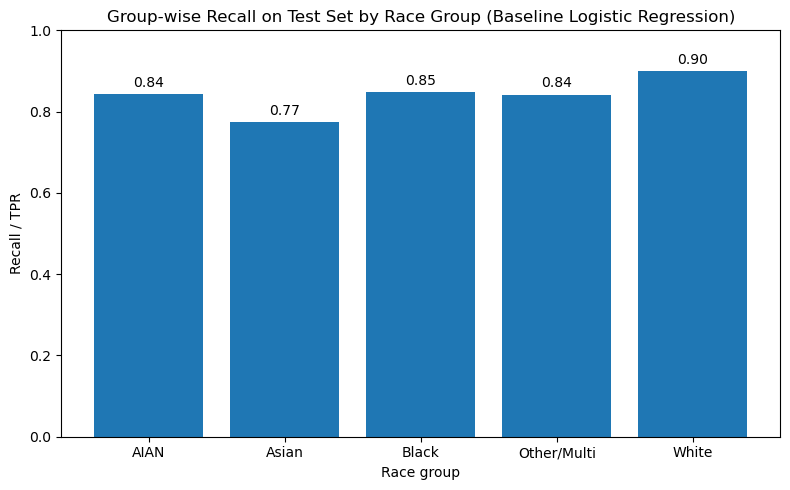

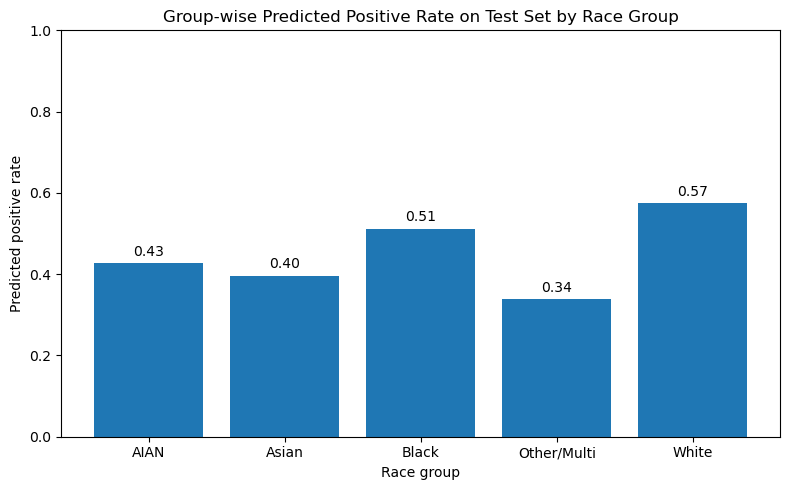

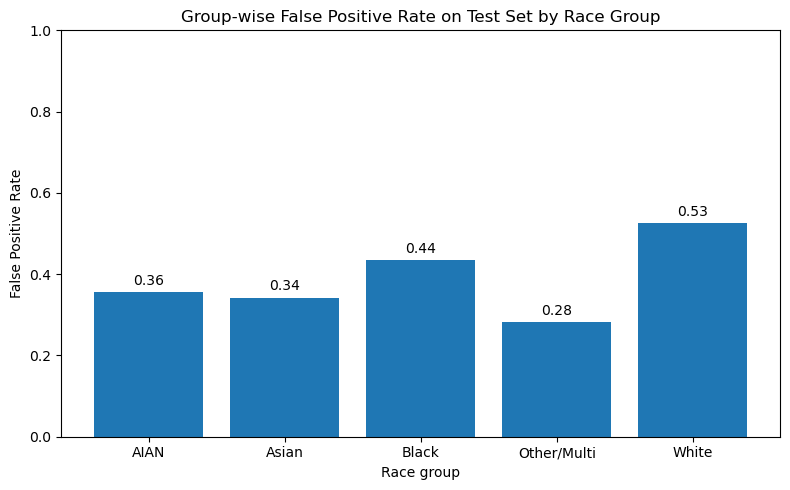

In [16]:
plot_df = group_metrics_df.copy()

# Plot 1: TPR / Recall
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["tpr"])
plt.xlabel("Race group")
plt.ylabel("Recall / TPR")
plt.title("Group-wise Recall on Test Set by Race Group (Baseline Logistic Regression)")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["tpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 2: Predicted positive rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["predicted_positive_rate"])
plt.xlabel("Race group")
plt.ylabel("Predicted positive rate")
plt.title("Group-wise Predicted Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["predicted_positive_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 3: False Positive Rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["fpr"])
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["fpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [17]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

pd.DataFrame([overall_metrics]).to_csv(
    output_dir / "baseline_logreg_overall_metrics.csv",
    index=False
)

group_metrics_df.to_csv(
    output_dir / "baseline_logreg_group_metrics.csv",
    index=False
)

print("Saved:")
print("- outputs/baseline_logreg_overall_metrics.csv")
print("- outputs/baseline_logreg_group_metrics.csv")

Saved:
- outputs/baseline_logreg_overall_metrics.csv
- outputs/baseline_logreg_group_metrics.csv


## Logistic regression without class_weight

In [18]:
log_reg_no_weight = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

log_reg_no_weight.fit(X_train, y_train)

print("Unweighted logistic regression pipeline fitted successfully.")
print("Features used:", categorical_features)

Unweighted logistic regression pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [19]:
y_pred_no_weight = log_reg_no_weight.predict(X_test)
y_prob_no_weight = log_reg_no_weight.predict_proba(X_test)[:, 1]

overall_metrics_no_weight = {
    "accuracy": accuracy_score(y_test, y_pred_no_weight),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_no_weight),
    "precision": precision_score(y_test, y_pred_no_weight, zero_division=0),
    "recall": recall_score(y_test, y_pred_no_weight, zero_division=0),
    "f1": f1_score(y_test, y_pred_no_weight, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_no_weight)
}

print("Overall metrics (no class_weight):")
for k, v in overall_metrics_no_weight.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_no_weight))

print("\nClassification report:")
print(classification_report(y_test, y_pred_no_weight, zero_division=0))

Overall metrics (no class_weight):
accuracy: 0.8642
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.7442

Confusion matrix:
[[29471     2]
 [ 4630     0]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     29473
           1       0.00      0.00      0.00      4630

    accuracy                           0.86     34103
   macro avg       0.43      0.50      0.46     34103
weighted avg       0.75      0.86      0.80     34103



In [20]:
group_results_no_weight = []

test_results_no_weight = X_test.copy()
test_results_no_weight["y_true"] = y_test.values
test_results_no_weight["y_pred"] = y_pred_no_weight
test_results_no_weight["y_prob"] = y_prob_no_weight
test_results_no_weight["race_group"] = protected_test.values

for grp in sorted(test_results_no_weight["race_group"].unique()):
    subset = test_results_no_weight[test_results_no_weight["race_group"] == grp].copy()

    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    group_results_no_weight.append({
        "race_group": grp,
        "n_samples": len(subset),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "positive_rate_true": subset["y_true"].mean(),
        "predicted_positive_rate": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "tpr": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_no_weight_df = (
    pd.DataFrame(group_results_no_weight)
    .sort_values("race_group")
    .reset_index(drop=True)
)

display(group_metrics_no_weight_df.round(6))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,348,0,0,297,51,0.146552,0.000000,0.853448,0.0,0.0,0.000000,1.000000,1.0,0.0
1,Asian,2226,0,0,1947,279,0.125337,0.000000,0.874663,0.0,0.0,0.000000,1.000000,1.0,0.0
2,Black,3843,0,1,3126,716,0.186313,0.000260,0.813427,0.0,0.0,0.000320,0.999680,1.0,0.0
3,Other/Multi,1129,0,0,1015,114,0.100974,0.000000,0.899026,0.0,0.0,0.000000,1.000000,1.0,0.0
4,White,26557,0,1,23086,3470,0.130662,0.000038,0.869300,0.0,0.0,0.000043,0.999957,1.0,0.0


In [21]:
comparison_df = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight}
]).round(4)

display(comparison_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.5571,0.6945,0.2192,0.8832,0.3513,0.7443
1,logreg_unweighted,0.8642,0.5000,0.0000,0.0000,0.0000,0.7442


The side-by-side comparison highlights a strong threshold-level trade-off. The class-weighted logistic regression model sacrifices overall accuracy in order to identify positive cases, while the unweighted model achieves superficially high accuracy by almost always predicting the majority class. This contrast shows why accuracy alone is not sufficient for evaluating imbalanced healthcare classification tasks.

In [22]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

pd.DataFrame([overall_metrics_no_weight]).to_csv(
    output_dir / "logreg_no_weight_overall_metrics.csv",
    index=False
)

group_metrics_no_weight_df.to_csv(
    output_dir / "logreg_no_weight_group_metrics.csv",
    index=False
)

comparison_df.to_csv(
    output_dir / "logreg_weight_comparison.csv",
    index=False
)

print("Saved:")
print("- outputs/logreg_no_weight_overall_metrics.csv")
print("- outputs/logreg_no_weight_group_metrics.csv")
print("- outputs/logreg_weight_comparison.csv")

Saved:
- outputs/logreg_no_weight_overall_metrics.csv
- outputs/logreg_no_weight_group_metrics.csv
- outputs/logreg_weight_comparison.csv


## Model Comparison and Fairness Analysis

In [23]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random forest pipeline fitted successfully.")
print("Features used:", categorical_features)

Random forest pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [24]:
overall_metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

print("Overall metrics (Random Forest):")
for k, v in overall_metrics_rf.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Overall metrics (Random Forest):
accuracy: 0.5647
balanced_accuracy: 0.6840
precision: 0.2173
recall: 0.8477
f1: 0.3459
roc_auc: 0.7279

Confusion matrix:
[[15333 14140]
 [  705  3925]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.52      0.67     29473
           1       0.22      0.85      0.35      4630

    accuracy                           0.56     34103
   macro avg       0.59      0.68      0.51     34103
weighted avg       0.86      0.56      0.63     34103



In [25]:
comparison_df_all = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight},
    {"model": "random_forest_balanced", **overall_metrics_rf}
]).round(4)

display(comparison_df_all)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.5571,0.6945,0.2192,0.8832,0.3513,0.7443
1,logreg_unweighted,0.8642,0.5000,0.0000,0.0000,0.0000,0.7442
2,random_forest_balanced,0.5647,0.6840,0.2173,0.8477,0.3459,0.7279


In [26]:
def build_group_metrics_df(X_test, y_test, y_pred, y_prob, protected_test, protected_col="race_group"):
    test_results = X_test.copy()
    test_results["y_true"] = y_test.values
    test_results["y_pred"] = y_pred
    test_results["y_prob"] = y_prob
    test_results[protected_col] = protected_test.values

    rows = []

    for grp in sorted(test_results[protected_col].unique()):
        subset = test_results[test_results[protected_col] == grp].copy()

        tn, fp, fn, tp = confusion_matrix(
            subset["y_true"], subset["y_pred"], labels=[0, 1]
        ).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "race_group": grp,
            "n_samples": len(subset),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "positive_rate_true": subset["y_true"].mean(),
            "predicted_positive_rate": subset["y_pred"].mean(),
            "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
            "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
            "tpr": tpr,
            "fpr": fpr,
            "tnr": tnr,
            "fnr": fnr,
            "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("race_group").reset_index(drop=True)

# Balanced logistic regression
group_metrics_logreg_df = build_group_metrics_df(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    protected_test=protected_test,
    protected_col="race_group"
)

# Random forest
group_metrics_rf_df = build_group_metrics_df(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    protected_test=protected_test,
    protected_col="race_group"
)

print("Balanced Logistic Regression:")
display(group_metrics_logreg_df.round(6))

print("Random Forest:")
display(group_metrics_rf_df.round(6))

Balanced Logistic Regression:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,348,43,106,191,8,0.146552,0.428161,0.672414,0.288591,0.843137,0.356902,0.643098,0.156863,0.430000
1,Asian,2226,216,667,1280,63,0.125337,0.396676,0.672058,0.244621,0.774194,0.342578,0.657422,0.225806,0.371773
2,Black,3843,608,1361,1766,108,0.186313,0.512360,0.617747,0.308786,0.849162,0.435241,0.564759,0.150838,0.452886
3,Other/Multi,1129,96,286,729,18,0.100974,0.338353,0.730735,0.251309,0.842105,0.281773,0.718227,0.157895,0.387097
4,White,26557,3126,12142,10945,344,0.130662,0.574914,0.529841,0.204742,0.900865,0.525924,0.474076,0.099135,0.333654


Random Forest:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,348,42,100,197,9,0.146552,0.408046,0.686782,0.295775,0.823529,0.336700,0.663300,0.176471,0.435233
1,Asian,2226,201,593,1354,78,0.125337,0.356694,0.698562,0.253149,0.720430,0.304571,0.695429,0.279570,0.374651
2,Black,3843,568,1322,1805,148,0.186313,0.491803,0.617486,0.300529,0.793296,0.422769,0.577231,0.206704,0.435917
3,Other/Multi,1129,88,279,736,26,0.100974,0.325066,0.729849,0.239782,0.771930,0.274877,0.725123,0.228070,0.365904
4,White,26557,3026,11846,11241,444,0.130662,0.560003,0.537222,0.203470,0.872046,0.513103,0.486897,0.127954,0.329953


In [27]:
fairness_compare_df = pd.concat([
    group_metrics_logreg_df.assign(model="logreg_balanced"),
    group_metrics_rf_df.assign(model="random_forest_balanced")
], ignore_index=True)

fairness_compare_df = fairness_compare_df[
    [
        "model", "race_group", "n_samples",
        "tpr", "fnr", "fpr", "tnr",
        "predicted_positive_rate"
    ]
].sort_values(["race_group", "model"]).reset_index(drop=True)

display(fairness_compare_df.round(6))

,model,race_group,n_samples,tpr,fnr,fpr,tnr,predicted_positive_rate
0,logreg_balanced,AIAN,348,0.843137,0.156863,0.356902,0.643098,0.428161
1,random_forest_balanced,AIAN,348,0.823529,0.176471,0.336700,0.663300,0.408046
2,logreg_balanced,Asian,2226,0.774194,0.225806,0.342578,0.657422,0.396676
3,random_forest_balanced,Asian,2226,0.720430,0.279570,0.304571,0.695429,0.356694
4,logreg_balanced,Black,3843,0.849162,0.150838,0.435241,0.564759,0.512360
5,random_forest_balanced,Black,3843,0.793296,0.206704,0.422769,0.577231,0.491803
6,logreg_balanced,Other/Multi,1129,0.842105,0.157895,0.281773,0.718227,0.338353
7,random_forest_balanced,Other/Multi,1129,0.771930,0.228070,0.274877,0.725123,0.325066
8,logreg_balanced,White,26557,0.900865,0.099135,0.525924,0.474076,0.574914
9,random_forest_balanced,White,26557,0.872046,0.127954,0.513103,0.486897,0.560003


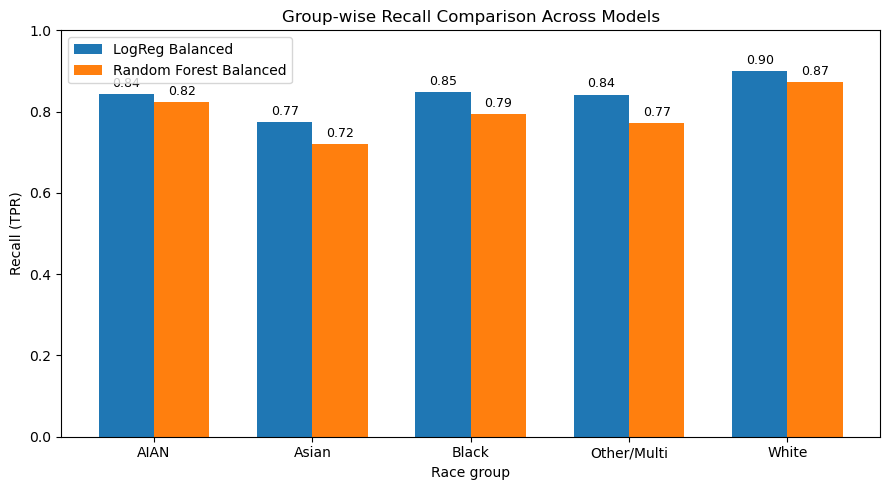

In [28]:
plot_logreg = group_metrics_logreg_df.copy()
plot_rf = group_metrics_rf_df.copy()

groups = plot_logreg["race_group"].tolist()
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["tpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["tpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Recall (TPR)")
plt.title("Group-wise Recall Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

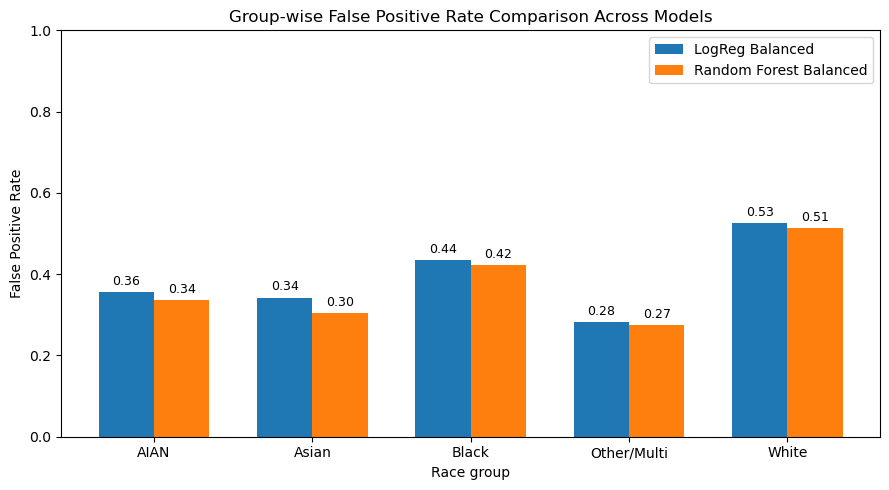

In [29]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["fpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["fpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

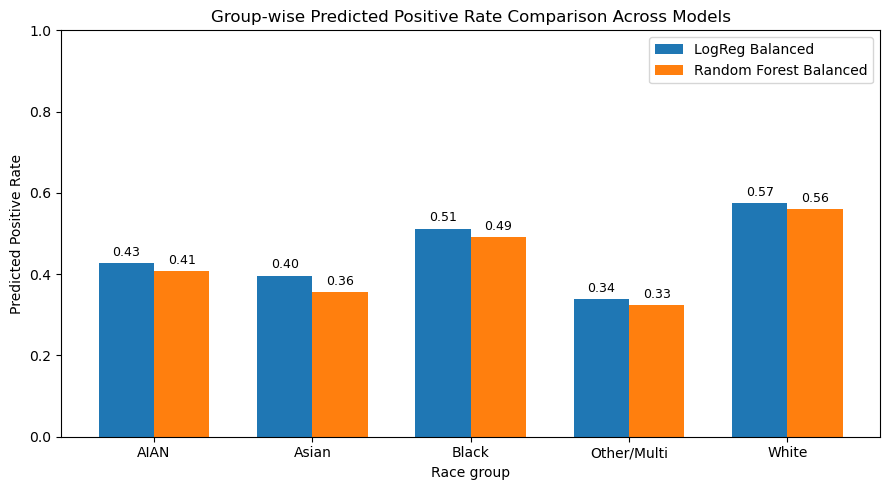

In [30]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["predicted_positive_rate"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["predicted_positive_rate"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Predicted Positive Rate")
plt.title("Group-wise Predicted Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [31]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

comparison_df_all.to_csv(
    output_dir / "model_comparison_overall_metrics.csv",
    index=False
)

group_metrics_logreg_df.to_csv(
    output_dir / "group_metrics_logreg_balanced.csv",
    index=False
)

group_metrics_rf_df.to_csv(
    output_dir / "group_metrics_random_forest_balanced.csv",
    index=False
)

fairness_compare_df.to_csv(
    output_dir / "fairness_metrics_across_models.csv",
    index=False
)

print("Saved:")
print("- outputs/model_comparison_overall_metrics.csv")
print("- outputs/group_metrics_logreg_balanced.csv")
print("- outputs/group_metrics_random_forest_balanced.csv")
print("- outputs/fairness_metrics_across_models.csv")

Saved:
- outputs/model_comparison_overall_metrics.csv
- outputs/group_metrics_logreg_balanced.csv
- outputs/group_metrics_random_forest_balanced.csv
- outputs/fairness_metrics_across_models.csv
